<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/PCA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Curse of Dimensionality

The phenomenon where adding more features (dimensions) to a dataset causes the data to become increasingly sparse — making distance calculations meaningless, models harder to train, and generalisation harder to achieve.

- Two main techniques to resolve it are

1.   Feature selection
2.   Feature extraction (Pca,lda,t-sne)



#PCA  Projects data onto a lower-dimensional space that captures **maximum variance** — compresses many correlated features into fewer uncorrelated components.

 - it is a feature extraction technique which is is used to counter curse of dimentionality

 Adv : - faster exec of algo

       - visualization

#Eigenvectors and Eigenvalues
Projects data onto a lower-dimensional space that captures maximum variance — compresses many correlated features into fewer uncorrelated components.

#PCA — steps:
Step 1 — Standardise the data

PCA is variance-based. Features with larger scales dominate. Always standardise first.

Step 2 — Compute covariance matrix

Captures how each feature varies with every other feature.


Step 3 — Compute eigenvectors and eigenvalues

Eigenvectors = principal component directions.


Eigenvalues = variance captured by each direction.


Step 4 — Sort by eigenvalue (descending)

The direction with the highest eigenvalue is PC1.


Step 5 — Project data onto top k components

Multiply original data by the top k eigenvectors → reduced dataset.

In [2]:
import pandas as pd
import numpy as np


In [21]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# You need to replace "" with the actual file name from the dataset, e.g., "train.csv"
file_path = "train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "animatronbot/mnist-digit-recognizer",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1380/3699200918.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mnist-digit-recognizer' dataset.
First 5 records:    label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0     

In [7]:
# Display the shape of the DataFrame
print(f"Dataset shape: {df.shape}")

# Display information about the DataFrame (columns, data types, non-null values)
df.info()

# Display descriptive statistics for numerical columns
display(df.describe())

Dataset shape: (42000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [8]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
22236,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


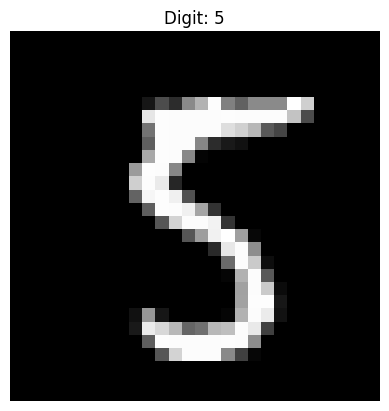

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the pixel data for the selected row, convert to numpy array, and reshape it
image_data = df.iloc[22236, 1:].values.reshape(28, 28)

# Display the image
plt.imshow(image_data, cmap='gray')
plt.title(f"Digit: {df.iloc[22236, 0]}") # Display the label of the digit
plt.axis('off') # Hide axes for cleaner image display
plt.show()

In [22]:
x = df.iloc[:,1:]
y = df.iloc[:,0]


In [23]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4)


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [16]:
import time
s = time.time()

y_pred = knn.predict(x_test)

e = time.time()
print(e-s)

16.16864562034607


In [17]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.965

#Now applying PCA

In [24]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)
x_train_trf.shape

(33600, 20)

In [36]:
knn = KNeighborsClassifier()
knn.fit(x_train_trf,y_train)


KNeighborsClassifier()

In [37]:
y_pred = knn.predict(x_test_trf)
accuracy_score(y_test,y_pred)

0.9407142857142857

optimmum number of components  : When accuracy reaches 90%

What PCA cannot do:
PCA is unsupervised — it finds directions of maximum variance without knowing the class labels. Maximum variance is not always the same as maximum class separability.
after projecting on this new PC the classes might mix

ex - imagine the data imform of ellipse where data in top left is blue and right bottom is red
and they are seperated in 45 degree anfle cut so the PC with most variance wont able to classify these classes

-It cannot handle complex, non-linear boundaries: